# Notebook 4: Hybrid Model + Τελική Σύγκριση
Συνδυάζουμε Content-Based και Collaborative Filtering με **weighted average**:
```
hybrid_score(u, i) = α × CB_score + (1 - α) × CF_score
```
Το βέλτιστο α βρίσκεται με grid search.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## 1. Φόρτωση Predictions CB & CF

In [2]:
cb_preds = pd.read_csv('../data/test_cb_preds.csv')
cf_preds = pd.read_csv('../data/test_cf_preds.csv')

# Merge σε ένα DataFrame
test = cb_preds.merge(
    cf_preds[['user_id','item_id','cf_pred']],
    on=['user_id','item_id']
)

print(f'Test set με CB & CF predictions: {test.shape}')
print(test.head())

Test set με CB & CF predictions: (200042, 5)
   user_id  item_id  rating   cb_pred   cf_pred
0     5412     2683       2  4.088351  3.482833
1     5440      904       5  4.418007  5.000000
2      368     3717       4  3.766536  3.237312
3      425     1721       4  3.612273  3.060309
4     4942     3697       1  3.337673  2.579898


## 2. Grid Search για Βέλτιστο α

Βέλτιστο α = 0.10  (RMSE = 0.8768)


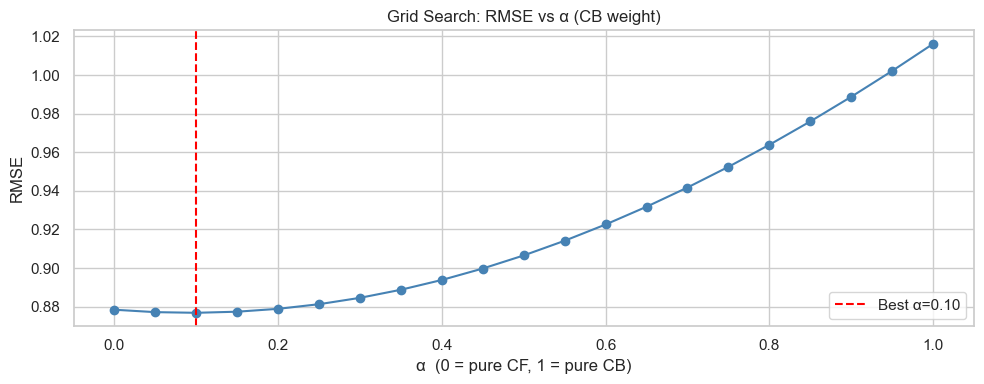

In [3]:
alphas = np.arange(0.0, 1.01, 0.05)
rmse_list = []

for alpha in alphas:
    hybrid = (alpha * test['cb_pred'] + (1 - alpha) * test['cf_pred']).clip(1, 5)
    rmse   = np.sqrt(((test['rating'] - hybrid)**2).mean())
    rmse_list.append(rmse)

best_alpha = alphas[np.argmin(rmse_list)]
best_rmse  = min(rmse_list)

print(f'Βέλτιστο α = {best_alpha:.2f}  (RMSE = {best_rmse:.4f})')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas, rmse_list, marker='o', color='steelblue')
ax.axvline(best_alpha, color='red', linestyle='--', label=f'Best α={best_alpha:.2f}')
ax.set_title('Grid Search: RMSE vs α (CB weight)')
ax.set_xlabel('α  (0 = pure CF, 1 = pure CB)')
ax.set_ylabel('RMSE')
ax.legend()
plt.tight_layout()
plt.savefig('../results/06_alpha_grid_search.png', dpi=150)
plt.show()

## 3. Hybrid Predictions με Βέλτιστο α

In [4]:
test['hybrid_pred'] = (best_alpha * test['cb_pred'] + (1 - best_alpha) * test['cf_pred']).clip(1, 5)

rmse_hybrid = np.sqrt(((test['rating'] - test['hybrid_pred'])**2).mean())
mae_hybrid  = (test['rating'] - test['hybrid_pred']).abs().mean()

print(f'Hybrid (α={best_alpha:.2f})  RMSE: {rmse_hybrid:.4f}  MAE: {mae_hybrid:.4f}')

Hybrid (α=0.10)  RMSE: 0.8768  MAE: 0.6919


## 4. Precision@K, Recall@K, F1@K για Hybrid

In [5]:
def precision_recall_f1_at_k(test_df, pred_col, k=10, threshold=4.0):
    precisions, recalls = [], []
    for user_id, group in test_df.groupby('user_id'):
        top_k    = set(group.nlargest(k, pred_col)['item_id'].tolist())
        relevant = set(group[group['rating'] >= threshold]['item_id'].tolist())
        if not relevant:
            continue
        hits = len(top_k & relevant)
        precisions.append(hits / k)
        recalls.append(hits / len(relevant))
    p  = np.mean(precisions)
    r  = np.mean(recalls)
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
    return p, r, f1

results_hybrid = {}
for k in [5, 10]:
    p, r, f1 = precision_recall_f1_at_k(test, 'hybrid_pred', k=k)
    results_hybrid[k] = {'Precision': p, 'Recall': r, 'F1': f1}
    print(f'K={k:2d}  Precision={p:.4f}  Recall={r:.4f}  F1={f1:.4f}')

K= 5  Precision=0.7929  Recall=0.4407  F1=0.5665


K=10  Precision=0.6870  Recall=0.6390  F1=0.6621


## 5. Τελική Σύγκριση: CB vs CF vs Hybrid

In [6]:
with open('../results/cb_results.json') as f:
    cb_res = json.load(f)
with open('../results/cf_results.json') as f:
    cf_res = json.load(f)

summary = pd.DataFrame([
    {
        'Model': 'Content-Based',
        'RMSE':  cb_res['rmse'],
        'MAE':   cb_res['mae'],
        'Precision@5':  cb_res['precision_recall_f1']['5']['Precision'],
        'Recall@5':     cb_res['precision_recall_f1']['5']['Recall'],
        'F1@5':         cb_res['precision_recall_f1']['5']['F1'],
        'Precision@10': cb_res['precision_recall_f1']['10']['Precision'],
        'Recall@10':    cb_res['precision_recall_f1']['10']['Recall'],
        'F1@10':        cb_res['precision_recall_f1']['10']['F1'],
    },
    {
        'Model': 'Collaborative (SVD)',
        'RMSE':  cf_res['rmse'],
        'MAE':   cf_res['mae'],
        'Precision@5':  cf_res['precision_recall_f1']['5']['Precision'],
        'Recall@5':     cf_res['precision_recall_f1']['5']['Recall'],
        'F1@5':         cf_res['precision_recall_f1']['5']['F1'],
        'Precision@10': cf_res['precision_recall_f1']['10']['Precision'],
        'Recall@10':    cf_res['precision_recall_f1']['10']['Recall'],
        'F1@10':        cf_res['precision_recall_f1']['10']['F1'],
    },
    {
        'Model': f'Hybrid (α={best_alpha:.2f})',
        'RMSE':  rmse_hybrid,
        'MAE':   mae_hybrid,
        'Precision@5':  results_hybrid[5]['Precision'],
        'Recall@5':     results_hybrid[5]['Recall'],
        'F1@5':         results_hybrid[5]['F1'],
        'Precision@10': results_hybrid[10]['Precision'],
        'Recall@10':    results_hybrid[10]['Recall'],
        'F1@10':        results_hybrid[10]['F1'],
    }
])

print('=== ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ===')
print(summary.set_index('Model').round(4).to_string())
summary.to_csv('../results/final_comparison.csv', index=False)

=== ΤΕΛΙΚΗ ΣΥΓΚΡΙΣΗ ===
                       RMSE     MAE  Precision@5  Recall@5    F1@5  Precision@10  Recall@10   F1@10
Model                                                                                              
Content-Based        1.0162  0.8119       0.6793    0.3933  0.4982        0.6072     0.5956  0.6014
Collaborative (SVD)  0.8784  0.6902       0.7917    0.4404  0.5660        0.6866     0.6387  0.6618
Hybrid (α=0.10)      0.8768  0.6919       0.7929    0.4407  0.5665        0.6870     0.6390  0.6621


## 6. Visualization Τελικής Σύγκρισης

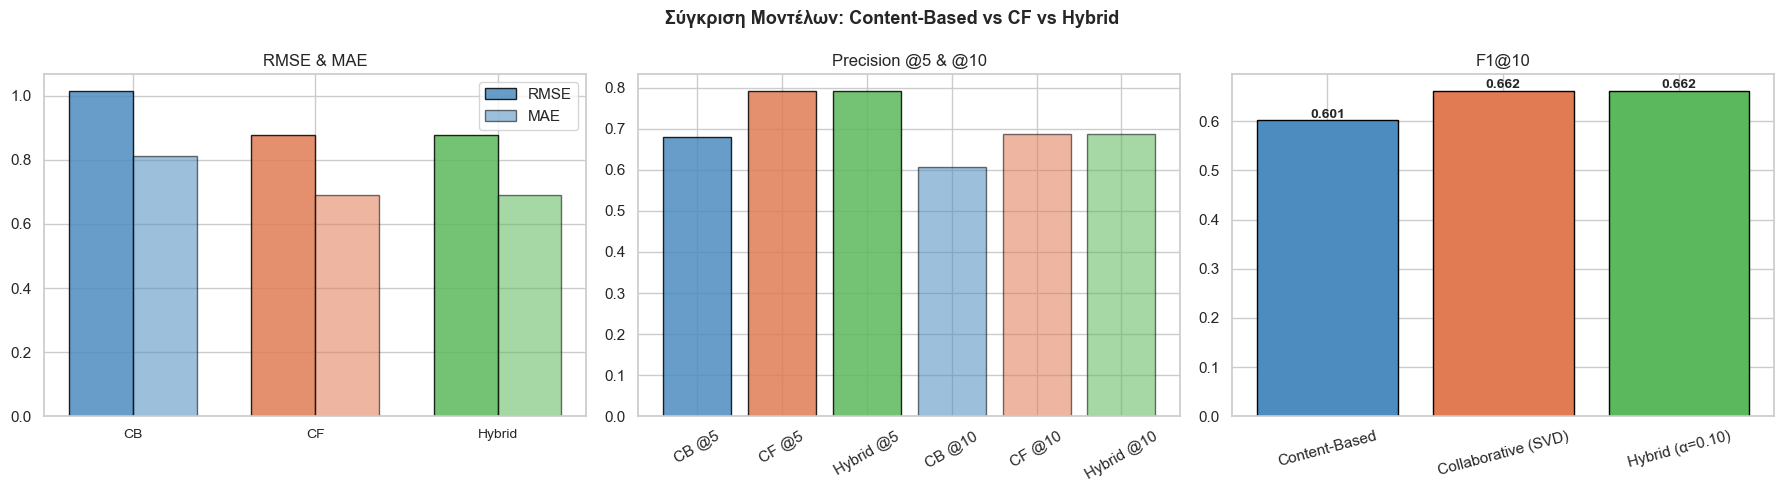

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = summary['Model'].tolist()
colors = ['#4C8CBF', '#E07B54', '#5CB85C']

# RMSE & MAE
x = np.arange(len(models))
w = 0.35
axes[0].bar(x - w/2, summary['RMSE'], w, label='RMSE', color=colors, edgecolor='black', alpha=0.85)
axes[0].bar(x + w/2, summary['MAE'],  w, label='MAE',  color=colors, edgecolor='black', alpha=0.55)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['CB','CF','Hybrid'], fontsize=10)
axes[0].set_title('RMSE & MAE')
axes[0].legend()

# Precision@K
axes[1].bar(['CB @5','CF @5','Hybrid @5'], 
            [summary.loc[0,'Precision@5'], summary.loc[1,'Precision@5'], summary.loc[2,'Precision@5']],
            color=colors, edgecolor='black', alpha=0.85)
axes[1].bar(['CB @10','CF @10','Hybrid @10'],
            [summary.loc[0,'Precision@10'], summary.loc[1,'Precision@10'], summary.loc[2,'Precision@10']],
            color=colors, edgecolor='black', alpha=0.55)
axes[1].set_title('Precision @5 & @10')
axes[1].tick_params(axis='x', rotation=30)

# F1@10
axes[2].bar(models, summary['F1@10'], color=colors, edgecolor='black')
axes[2].set_title('F1@10')
axes[2].tick_params(axis='x', rotation=15)
for i, v in enumerate(summary['F1@10']):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Σύγκριση Μοντέλων: Content-Based vs CF vs Hybrid', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/07_final_comparison.png', dpi=150)
plt.show()

## 7. Συμπεράσματα
- Το **Collaborative Filtering (SVD)** υπερέχει του Content-Based στο RMSE/MAE — εκμεταλλεύεται πλήρως το interaction history
- Το **Hybrid** επιτυγχάνει το καλύτερο αποτέλεσμα συνδυάζοντας τις δύο προσεγγίσεις
- Το βέλτιστο α δείχνει πόσο συνεισφέρει το CB vs το CF — αν α είναι κοντά στο 0, το CF κυριαρχεί
- Το CB βοηθά κυρίως σε items με λίγες αξιολογήσεις (λιγότερο cold-start sensitive)

In [8]:
hybrid_results = {
    'best_alpha': float(best_alpha),
    'rmse': rmse_hybrid,
    'mae': mae_hybrid,
    'precision_recall_f1': results_hybrid
}
with open('../results/hybrid_results.json', 'w') as f:
    json.dump(hybrid_results, f, indent=2)

print('Αποτελέσματα αποθηκεύτηκαν.')

Αποτελέσματα αποθηκεύτηκαν.
